In [1]:
import mne
from mne.time_frequency import tfr_morlet, stft
import numpy as np
import matplotlib as plt
import pywt
import h5py
from temporaldata import Data
from pathlib import Path
import gc
import pandas as pd
import re


from io import StringIO
from mne.channels import generate_2d_layout


import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize


In [24]:
print(data.keys())

['acoustic_stim_trials', 'brainset', 'channels', 'device', 'ecog', 'on_vs_off_trials', 'session', 'splits', 'subject']


In [171]:
def var_calc(data, freq_filter=None, sfreq=2000):

	
	signal = []

	if freq_filter is None:
		starts = data.acoustic_stim_trials.start
		ends = data.acoustic_stim_trials.end
	else:
		starts = data.acoustic_stim_trials.start[data.acoustic_stim_trials.behavior_labels == freq_filter]
		ends = data.acoustic_stim_trials.end[data.acoustic_stim_trials.behavior_labels == freq_filter]

	ecog = data.ecog.signal[:, data.channels.type == "ecog"]
	timestamps = data.ecog.timestamps

	eps = np.finfo(float).eps

	for start, end in zip(starts, ends):
		try:
			b_start = np.searchsorted(timestamps, (start - 0.4))
			b_end = np.searchsorted(timestamps, (start - 0.1))

			baseline = ecog[b_start:b_end, :].T
			base_mean = np.mean(baseline, axis=1, keepdims=True)
			base_power = np.mean((baseline - base_mean) ** 2, axis=1)

			freq_power = np.mean(((ecog[np.searchsorted(timestamps, start):np.searchsorted(timestamps, end), :].T - base_mean) ** 2), axis=1)

			log_power_ratio = (np.log((freq_power + eps) / (base_power + eps)))

			if not np.isnan(np.sum(log_power_ratio)):
				signal.append(log_power_ratio)
			# else:
			# 	print(log_power_ratio)
			# 	print(f"{b_start}, {b_end}")
			# 	print(base_mean)
			# 	print(base_power)
			# 	print("------------------------------------------------------------------")
		except Exception as e:
			print(e)
			continue

	if len(signal) == 0:
		return None
	else:
		return np.mean(signal, axis=0)


In [147]:
with h5py.File(Path(SOURCE + "/" + sessions[1])) as f:
		data = Data.from_hdf5(f, lazy=False)

In [101]:
print(data.acoustic_stim_trials.start)

[6.175000e-01 1.617500e+00 2.617500e+00 3.617500e+00 4.617500e+00
 5.617500e+00 6.617500e+00 7.617500e+00 8.617500e+00 9.617500e+00
 1.061750e+01 1.161750e+01 1.261750e+01 1.361750e+01 1.461750e+01
 1.561750e+01 1.661750e+01 1.761750e+01 1.861750e+01 1.961750e+01
 2.061750e+01 2.161750e+01 2.261750e+01 2.361750e+01 1.137825e+02
 1.147825e+02 1.157825e+02 1.167825e+02 1.177825e+02 1.187825e+02
 1.197825e+02 1.207825e+02 1.217825e+02 1.227825e+02 1.237825e+02
 1.247825e+02 1.257825e+02 1.267825e+02 1.277825e+02 1.287825e+02
 1.297825e+02 1.307825e+02 1.317825e+02 1.327825e+02 1.337825e+02
 1.347825e+02 1.357825e+02 1.367825e+02 1.377825e+02 1.387825e+02
 1.397825e+02 1.407825e+02 1.417825e+02 1.427825e+02 1.437825e+02
 1.447825e+02 1.457825e+02 1.467825e+02 8.110000e+02 8.120000e+02
 8.130000e+02 8.140000e+02 8.150000e+02 8.160000e+02 8.170000e+02
 8.180000e+02 8.190000e+02 8.200000e+02 8.210000e+02 8.220000e+02
 8.230000e+02 8.240000e+02 8.250000e+02 8.260000e+02 8.270000e+02
 8.280000e

In [125]:
print(len(data.ecog.timestamps) / (data.ecog.timestamps[-1] - data.ecog.timestamps[0]))

768.89669572044


In [126]:
dt = np.diff(data.ecog.timestamps)

In [127]:
print(dt.min())
print(dt.max())
print(dt.mean())

0.0004999999998744897
663.2005
0.0013005659782423405


In [118]:
print(data.ecog.signal.shape)

(1132200, 32)


In [112]:
print(data.acoustic_stim_trials.start[-1])

1616.314


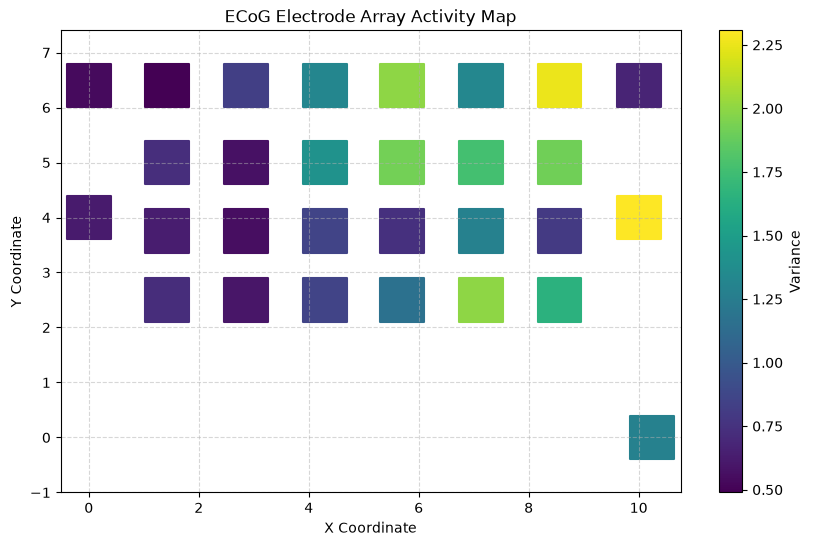

In [165]:
plot_grid(var_calc(data, freq_filter="stim_20000Hz"))

In [3]:
def std_calc(datasets, durations):

	num_samples = np.array(durations)

	data = np.stack(datasets)[num_samples > 0]

	num_samples = num_samples[num_samples > 0]

	# sum (sigma_i * num(sigma_i_duration)) / total_duration
	grand_var = np.sum(data * num_samples[:, np.newaxis], axis=0) / np.sum(num_samples)

	return grand_var, np.sqrt(grand_var)


In [4]:
def plot_grid(data):
    plt.figure(figsize=(10, 6))

    scatter = plt.scatter(
        df["x"],
        df["y"],
        c=data,
        cmap="viridis",
        s=1000,
        marker = 's',
        # edgecolors="black",
        linewidths=1.5,
    )

    # for idx, row in df.iterrows():
    #     plt.text(
    #         row["x"],
    #         row["y"] + 0.15,  # Slightly offset text vertically
    #         row["name"],
    #         fontsize=9,
    #         ha="center",
    #         weight="bold",
    #     )

    plt.colorbar(scatter, label="Variance")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.title("ECoG Electrode Array Activity Map")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.axis("equal")

    plt.show()

In [5]:
csv_path = "/capstor/store/cscs/swissai/a0091/data/nsb-monkeys-v1.1/sub-01/ses-01/ieeg/sub-01_ses-01_acq-RH_electrodes.tsv"

df = pd.read_csv(Path(csv_path), sep="\t")


df = df[df['x'].notna() & df['y'].notna() & df['z'].notna()]

names = df["name"].tolist()



print(df)
xy = df[["x", "y"]].to_numpy()
 
layout = generate_2d_layout(
    xy,
    w=0.05,
    h=0.05,
    pad=0.05,
    ch_names=names,
    name="SG3D1",
    normalize=True,
)
 
print(layout)
print("box:", layout.box)
print("pos shape:", layout.pos.shape)
print("first 3 rows of pos (x, y, w, h):")
print(layout.pos[:3])


        name      x     y    z  size  impedance
2    SG3D1E8   0.00  4.00  0.0   0.3        NaN
3   SG3D1E22   0.00  6.40  0.0   0.3        NaN
4   SG3D1E16   1.43  5.00  0.0   0.3        NaN
5    SG3D1E9   1.43  3.75  0.0   0.3        NaN
6    SG3D1E2   1.43  2.50  0.0   0.3        NaN
7   SG3D1E23   1.43  6.40  0.0   0.3        NaN
8   SG3D1E17   2.86  5.00  0.0   0.3        NaN
9   SG3D1E10   2.86  3.75  0.0   0.3        NaN
10   SG3D1E3   2.86  2.50  0.0   0.3        NaN
11  SG3D1E24   2.86  6.40  0.0   0.3        NaN
12  SG3D1E18   4.30  5.00  0.0   0.3        NaN
13  SG3D1E11   4.30  3.75  0.0   0.3        NaN
14   SG3D1E4   4.30  2.50  0.0   0.3        NaN
15  SG3D1E25   4.30  6.40  0.0   0.3        NaN
16  SG3D1E26   5.70  6.40  0.0   0.3        NaN
17   SG3D1E5   5.70  2.50  0.0   0.3        NaN
18  SG3D1E12   5.70  3.75  0.0   0.3        NaN
19  SG3D1E19   5.70  5.00  0.0   0.3        NaN
20  SG3D1E27   7.13  6.40  0.0   0.3        NaN
21   SG3D1E6   7.13  2.50  0.0   0.3    

In [99]:
SOURCE = r"/capstor/store/cscs/swissai/a0091/processed/neurosoft_monkeys_2026"

# SOURCE = r"/capstor/store/cscs/swissai/a0091/processed/neurosoft_minipigs_2026"

In [7]:
sessions = [
    f"sub-01_ses-0{i}_task-AcousStim_acq-RH_desc-raw.h5"
    for i in range(1, 17)
]

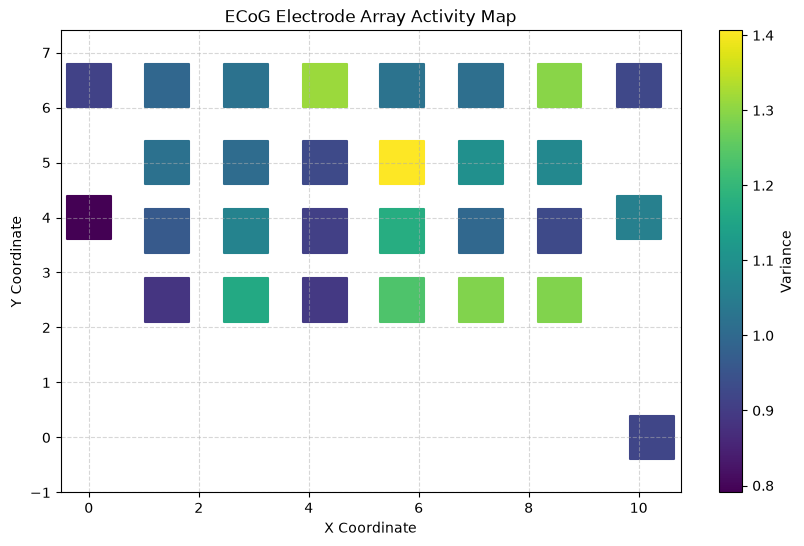

In [181]:
FREQ="stim_4000Hz"

grids = []
durations = []

for session in sessions:
	with h5py.File(Path(SOURCE + "/" + session)) as f:
		data = Data.from_hdf5(f, lazy=False)

	out = var_calc(data, freq_filter=FREQ)

	if out is not None:
		grids.append(out)

grand_stats = np.mean(grids, axis=0)

plot_grid(grand_stats)

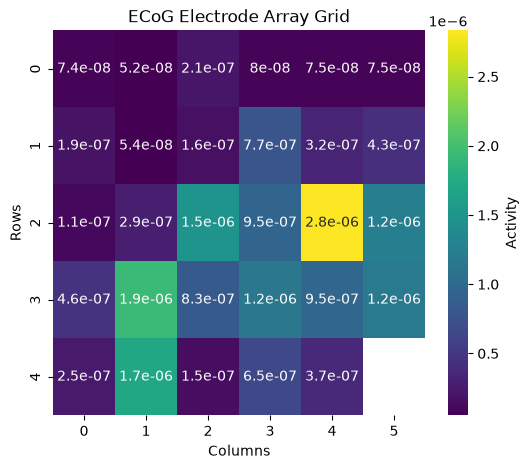

In [ ]:
import seaborn as sns

# (29,) data array 
activity_data = var_calc(data)

padded_data = np.append(activity_data, np.nan)
grid_data = padded_data.reshape(5, 6)

plt.figure(figsize=(6, 5))
sns.heatmap(grid_data, annot=True, cmap="viridis", cbar_kws={"label": "Activity"})
plt.title("ECoG Electrode Array Grid")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

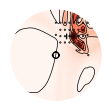

(<matplotlib.image.AxesImage at 0x4001b670ae50>,
 <matplotlib.contour.QuadContourSet at 0x4001b670b9d0>)

In [ ]:
mne.viz.plot_topomap(var_calc(data), layout.pos[:,:2])